In [1]:
import sys
sys.path.append('..')
from src.preprocessing import preprocess
from src.train import train_random_forest, train_svm

# Preprocessing
X_train, X_test, y_train, y_test = preprocess(
    "../data/Scenario A1-ARFF/TimeBasedFeatures-Dataset-15s-VPN.arff"
)

# Entrenar modelos
rf = train_random_forest(X_train, y_train)
svm = train_svm(X_train, y_train)


Dataset cargado: (18758, 24)
Filas eliminadas por outliers: 163
Dataset tras outliers: (18595, 24)
Scaler guardado en models/scaler.pkl
Train: (14876, 23) | Test: (3719, 23)
Entrenando Random Forest...
Random Forest CV Accuracy: 0.9137 (+/- 0.0073)
Modelo guardado en models/random_forest.pkl
Entrenando SVM...


/home/insomne/Clasificador-Trafico-Encriptado/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/insomne/Clasificador-Trafico-Encriptado/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/insomne/Clasificador-Trafico-Encriptado/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/insomne/Clasificador-Trafico-Encriptado/venv/lib/python3.1

SVM CV Accuracy: 0.6379 (+/- 0.0086)
Modelo guardado en models/svm.pkl


In [3]:
import sys
sys.path.append('..')
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_curve, auc)

# Cargar modelos
rf = joblib.load('../models/random_forest.pkl')
svm = joblib.load('../models/svm.pkl')

# Predicciones
rf_pred = rf.predict(X_test)
svm_pred = svm.predict(X_test)

# Reports
print("=== RANDOM FOREST ===")
print(classification_report(y_test, rf_pred, target_names=['Non-VPN', 'VPN']))

print("=== SVM ===")
print(classification_report(y_test, svm_pred, target_names=['Non-VPN', 'VPN']))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

     Non-VPN       0.93      0.89      0.91      1771
         VPN       0.90      0.94      0.92      1948

    accuracy                           0.91      3719
   macro avg       0.92      0.91      0.91      3719
weighted avg       0.91      0.91      0.91      3719

=== SVM ===
              precision    recall  f1-score   support

     Non-VPN       0.69      0.46      0.55      1771
         VPN       0.62      0.81      0.70      1948

    accuracy                           0.64      3719
   macro avg       0.66      0.63      0.63      3719
weighted avg       0.65      0.64      0.63      3719



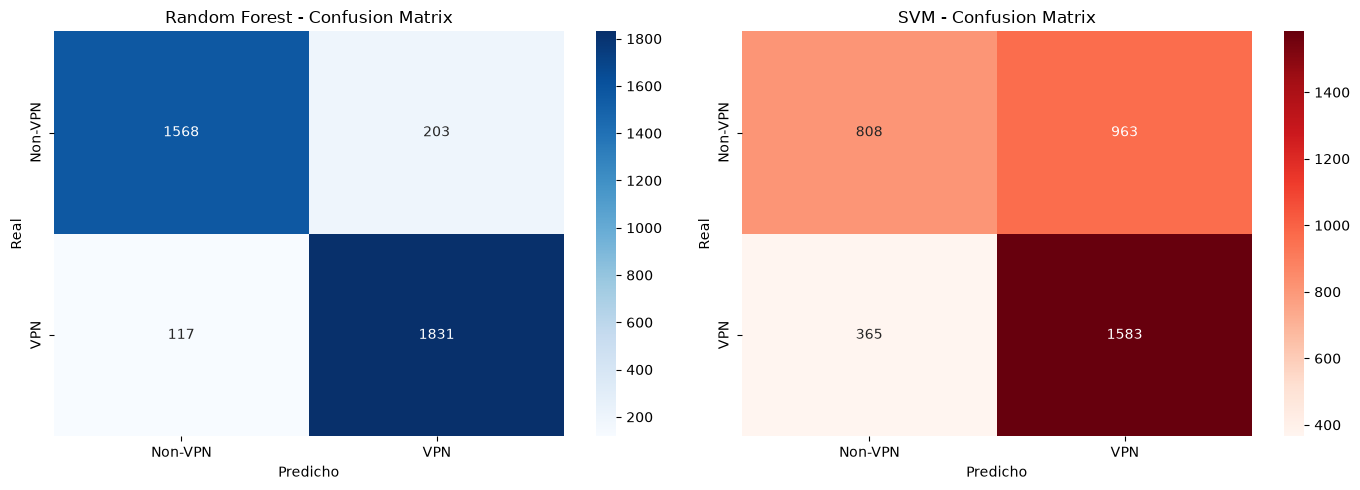

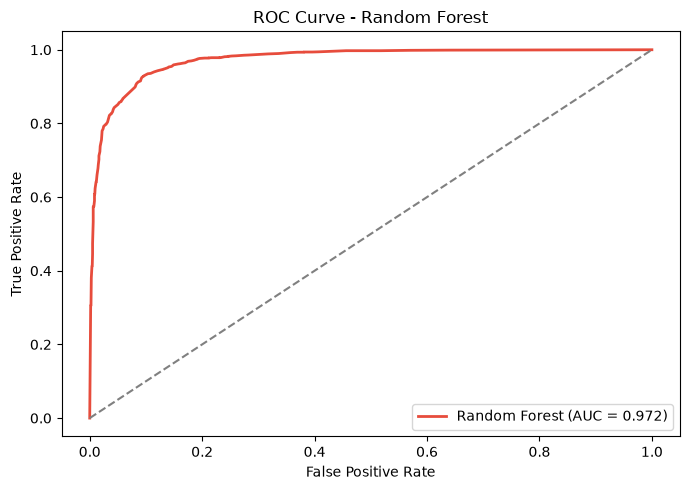

AUC-ROC: 0.9725


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix - Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-VPN', 'VPN'], yticklabels=['Non-VPN', 'VPN'])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Confusion matrix - SVM
cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Non-VPN', 'VPN'], yticklabels=['Non-VPN', 'VPN'])
axes[1].set_title('SVM - Confusion Matrix')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curve - solo Random Forest
rf_proba = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('../results/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")